# __Wearable dataset normalization - per patient__

Ilina Durakovska 

__Dataset:__ Wearable Device Dataset from Induced Stress and Structured Exercise Sessions \
__Physionet Link:__ [https://physionet.org/content/wearable-device-dataset/1.0.1/](https://physionet.org/content/wearable-device-dataset/1.0.1/) \
__Kaggle (unofficial) Link:__ [https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise](https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise)

In [55]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
warnings.filterwarnings("ignore")

---

## __Why are we doing this?__

Seeing the poor preformance with the updated dataset when training the classification models, I wanted to try something new.

Instead of just looking at the values of the parameters we can extract at face value, we can try normalizing them per patient. By this I mean taking the average resting value of a variable (lets say bpm) per person, and subtracting that resting average from every window for that person - giving us a new delta variable to work with. 

The idea is that despite having differing base values, the participants might have simmilar changes when entering a different phisiological state. So let's try this out:

---

## __Loading the updated data__

In [13]:
df = pd.read_csv("wearable_dataset_windows_updated.csv")

In [24]:
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])

In [28]:
# df

## __Taking baseline features__

In [34]:
BASELINE_FEATURES = [
    "hp_bpm", "hp_ibi", "hp_sdnn", "hp_rmssd", "hp_hr_mad", "hp_breathingrate",
    "eda_mean", "eda_phasic_mean",
    "temp_mean",
]

In [36]:
rest_df = df[df["state_label"] == "rest"]

In [38]:
baseline = (
    rest_df.groupby("patient_id")[BASELINE_FEATURES]
    .mean()
    .add_suffix("_baseline")
)

In [42]:
baseline

,hp_bpm_baseline,hp_ibi_baseline,hp_sdnn_baseline,hp_rmssd_baseline,hp_hr_mad_baseline,hp_breathingrate_baseline,eda_mean_baseline,eda_phasic_mean_baseline,temp_mean_baseline
patient_id,,,,,,,,,
S01,76.716294,800.413375,153.975572,196.288033,108.496094,0.215372,1.256382,0.000121,33.225465
S02,91.301866,670.073910,75.668221,88.861572,42.308273,0.195600,3.486512,0.000197,54.880057
S03,85.757707,714.674825,146.845455,179.731558,92.295259,0.218875,2.015752,0.000130,31.671563
S04,80.119630,808.559078,115.592280,136.378093,71.559176,0.205458,4.980991,0.000044,32.933395
S05,88.652572,696.194143,124.508786,154.623792,79.545455,0.186127,16.443122,0.000101,57.702124
S06,101.382215,622.182217,88.218389,106.986616,44.649621,0.201667,3.958683,0.000294,33.232312
S07,83.923571,730.294380,143.456104,184.165565,104.833984,0.225228,0.283308,0.000056,30.559264
S08,79.663170,789.015058,123.042182,149.240293,74.922360,0.208340,2.534021,0.000050,33.147211
S09,90.150083,700.592002,96.709797,115.619913,62.404141,0.186931,1.322413,0.000068,33.212685


In [44]:
df_norm = df.merge(baseline, on="patient_id", how="left")

## __Adding delta features__

In [46]:
for feat in BASELINE_FEATURES:
    df_norm[f"delta_{feat}"] = df_norm[feat] - df_norm[f"{feat}_baseline"]

In [50]:
df_norm[["patient_id", "state_label", "hp_bpm", "hp_bpm_baseline", "delta_hp_bpm"]].head(10)

,patient_id,state_label,hp_bpm,hp_bpm_baseline,delta_hp_bpm
0,S01,aerobic,99.426172,76.716294,22.709878
1,S01,aerobic,99.355904,76.716294,22.639610
2,S01,aerobic,99.310345,76.716294,22.594050
3,S01,aerobic,98.942229,76.716294,22.225935
4,S01,aerobic,98.382706,76.716294,21.666412
5,S01,aerobic,97.696840,76.716294,20.980545
6,S01,aerobic,97.360960,76.716294,20.644665
7,S01,aerobic,97.006181,76.716294,20.289887
8,S01,aerobic,97.387510,76.716294,20.671216
9,S01,aerobic,96.736035,76.716294,20.019741


## __Visual check:__

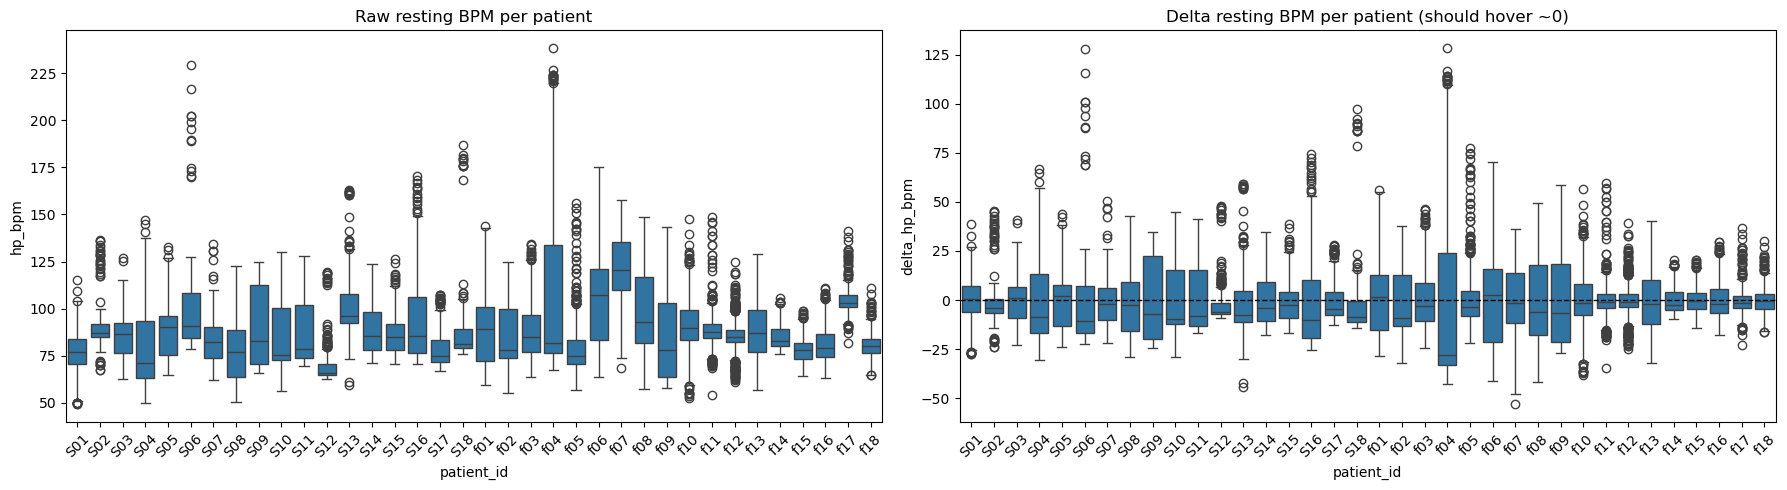

In [57]:
rest_check = df_norm[df_norm["state_label"] == "rest"]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(data=rest_check, x="patient_id", y="hp_bpm",
            order=sorted(rest_check["patient_id"].unique()), ax=axes[0])
axes[0].set_title("Raw resting BPM per patient")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=rest_check, x="patient_id", y="delta_hp_bpm",
            order=sorted(rest_check["patient_id"].unique()), ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Delta resting BPM per patient (should hover ~0)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## __Saving the new dataset:__

In [78]:
baseline_cols = [f"{feat}_baseline" for feat in BASELINE_FEATURES]

In [80]:
df_to_save = df_norm.drop(columns=baseline_cols)

In [84]:
# df_to_save

In [87]:
df_to_save.to_csv("wearable_dataset_windows_normalized.csv", index=False)